In [ ]:
!pip install lightgbm --quiet

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings, os
from datetime import date, timedelta

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 150})

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/My Drive/Colab Notebooks/Warehouse_Order_Forecast"
OUT_DIR  = DATA_DIR     # save outputs to same folder
WH_ID    = "WH001"

print(f"📂 Data directory: {DATA_DIR}")
print(f"🏭 Target warehouse: {WH_ID}\n")

Mounted at /content/drive
📂 Data directory: /content/drive/My Drive/Colab Notebooks/Warehouse_Order_Forecast
🏭 Target warehouse: WH001



In [ ]:
print("📥 Loading CSVs …")

# Load only WH001 orders from header
hdr = pd.read_csv(
    f"{DATA_DIR}/fact_orders_header.csv",
    usecols=["order_id", "order_date", "warehouse_id"],
    parse_dates=["order_date"],
)
hdr = hdr[hdr["warehouse_id"] == WH_ID].copy()
print(f"   ✔ Header rows for {WH_ID}: {len(hdr):,}")

# Load detail in chunks — keep only matching order_ids
valid_ids = set(hdr["order_id"])
detail_chunks = []
for chunk in pd.read_csv(f"{DATA_DIR}/fact_orders_detail.csv",
                         usecols=["order_id", "product_id", "ordered_qty"],
                         chunksize=500_000):
    detail_chunks.append(chunk[chunk["order_id"].isin(valid_ids)])

detail = pd.concat(detail_chunks, ignore_index=True)
print(f"   ✔ Detail rows for {WH_ID}: {len(detail):,}")

# Join & aggregate → daily grain per SKU
df = detail.merge(hdr[["order_id", "order_date"]], on="order_id")
daily = (
    df.groupby(["order_date", "product_id"], as_index=False)["ordered_qty"]
    .sum()
    .rename(columns={"ordered_qty": "total_qty"})
)
daily["order_date"] = pd.to_datetime(daily["order_date"])
daily = daily.sort_values(["product_id", "order_date"]).reset_index(drop=True)
print(f"   ✔ Daily-grain rows: {len(daily):,}")

📥 Loading CSVs …
   ✔ Header rows for WH001: 200,000
   ✔ Detail rows for WH001: 601,213
   ✔ Daily-grain rows: 388,601


In [ ]:
# ══════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════
print("\n🔧 Engineering features …")

LAG_DAYS    = [7, 14, 21]
ROLL_WINS   = [7, 14]

all_skus      = daily["product_id"].unique()
full_date_idx = pd.date_range(daily["order_date"].min(), daily["order_date"].max(), freq="D")

feature_frames = []

for sku in all_skus:
    sub = (
        daily[daily["product_id"] == sku]
        .set_index("order_date")
        .reindex(full_date_idx)          # fill missing dates
        .fillna(0)
        .rename_axis("order_date")
        .reset_index()
    )
    sub["product_id"] = sku

    # Time features
    sub["day_of_week"] = sub["order_date"].dt.dayofweek          # 0=Mon
    sub["month"]       = sub["order_date"].dt.month
    sub["day_of_year"] = sub["order_date"].dt.dayofyear
    sub["year"]        = sub["order_date"].dt.year
    sub["week"]        = sub["order_date"].dt.isocalendar().week.astype(int)
    sub["is_weekend"]  = (sub["day_of_week"] >= 5).astype(int)

    # Lag features
    for lag in LAG_DAYS:
        sub[f"lag_{lag}"] = sub["total_qty"].shift(lag)

    # Rolling means
    for win in ROLL_WINS:
        sub[f"rolling_mean_{win}"] = sub["total_qty"].shift(1).rolling(win).mean()

    feature_frames.append(sub)

features = pd.concat(feature_frames, ignore_index=True)
features = features.dropna()   # remove rows where lags are NaN
print(f"   ✔ Feature matrix: {len(features):,} rows × {features.shape[1]} cols")



🔧 Engineering features …
   ✔ Feature matrix: 864,000 rows × 14 cols


In [ ]:
# ══════════════════════════════════════════════════════════════
# 4. TRAIN / TEST SPLIT  (last 90 days = test)
# ══════════════════════════════════════════════════════════════
print("\n📊 Splitting train / test …")

FEATURE_COLS = (
    ["day_of_week", "month", "day_of_year", "year", "week", "is_weekend"]
    + [f"lag_{l}" for l in LAG_DAYS]
    + [f"rolling_mean_{w}" for w in ROLL_WINS]
)
TARGET = "total_qty"

cutoff   = features["order_date"].max() - pd.Timedelta(days=90)
train_df = features[features["order_date"] <= cutoff].copy()
test_df  = features[features["order_date"] >  cutoff].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

print(f"   ✔ Train: {len(train_df):,} rows  |  Test: {len(test_df):,} rows")

# Save train/test CSVs
train_out = train_df[["order_date", "product_id"] + FEATURE_COLS + [TARGET]]
test_out  = test_df[["order_date", "product_id"]  + FEATURE_COLS + [TARGET]]
train_out.to_csv(f"{OUT_DIR}/train_dataset.csv", index=False)
test_out.to_csv(f"{OUT_DIR}/test_dataset.csv",  index=False)
print(f"   💾 Saved train_dataset.csv & test_dataset.csv")


📊 Splitting train / test …
   ✔ Train: 810,000 rows  |  Test: 54,000 rows
   💾 Saved train_dataset.csv & test_dataset.csv


In [ ]:
# ══════════════════════════════════════════════════════════════
# 5. TRAIN LIGHTGBM
# ══════════════════════════════════════════════════════════════
print("\n🚀 Training LightGBM …")

params = {
    "objective":       "regression",
    "metric":          "rmse",
    "learning_rate":   0.05,
    "num_leaves":      63,
    "min_child_samples": 20,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":    5,
    "n_estimators":    500,
    "verbose":        -1,
    "random_state":    42,
}

model = lgb.LGBMRegressor(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

test_preds = model.predict(X_test)
rmse = np.sqrt(np.mean((test_preds - y_test.values) ** 2))
mae  = np.mean(np.abs(test_preds - y_test.values))
print(f"\n   📈 Test RMSE : {rmse:.2f}")
print(f"   📉 Test MAE  : {mae:.2f}")



🚀 Training LightGBM …
[100]	valid_0's rmse: 24.4868

   📈 Test RMSE : 24.48
   📉 Test MAE  : 18.13


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6. RECURSIVE 7-DAY FORECAST  (next 7 days from today)
# ══════════════════════════════════════════════════════════════
print("\n🔮 Generating 7-day recursive forecast …")

today         = pd.Timestamp(date.today())
forecast_dates = pd.date_range(today + pd.Timedelta(days=1), periods=7, freq="D")
print(f"   Forecast window: {forecast_dates[0].date()} → {forecast_dates[-1].date()}")

# Build a per-SKU history dict for fast lag lookup
hist_dict = {}
for sku in all_skus:
    sub = (
        daily[daily["product_id"] == sku]
        .set_index("order_date")["total_qty"]
        .reindex(full_date_idx, fill_value=0)
    )
    hist_dict[sku] = sub.copy()

forecast_rows = []

for fdate in forecast_dates:
    for sku in all_skus:
        hist = hist_dict[sku]

        lags = {}
        for lag in LAG_DAYS:
            ref = fdate - pd.Timedelta(days=lag)
            lags[f"lag_{lag}"] = hist.get(ref, 0)

        rolls = {}
        for win in ROLL_WINS:
            vals = [hist.get(fdate - pd.Timedelta(days=d), 0) for d in range(1, win + 1)]
            rolls[f"rolling_mean_{win}"] = np.mean(vals)

        row = {
            "day_of_week": fdate.dayofweek,
            "month":       fdate.month,
            "day_of_year": fdate.dayofyear,
            "year":        fdate.year,
            "week":        fdate.isocalendar()[1],
            "is_weekend":  int(fdate.dayofweek >= 5),
            **lags,
            **rolls,
        }

        pred = max(0, model.predict(pd.DataFrame([row])[FEATURE_COLS])[0])

        forecast_rows.append({
            "forecast_date": fdate.date(),
            "product_id":    sku,
            "predicted_qty": round(pred, 2),
        })

        # Feed prediction back into history for next lag
        hist_dict[sku][fdate] = pred

forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv(f"{OUT_DIR}/lgbm_forecast_7day.csv", index=False)
print(f"   ✔ Forecast saved: lgbm_forecast_7day.csv  ({len(forecast_df):,} rows)")

# Aggregate across all SKUs for a warehouse-level view
wh_forecast = (
    forecast_df.groupby("forecast_date")["predicted_qty"]
    .sum()
    .reset_index()
    .rename(columns={"predicted_qty": "total_predicted_qty"})
)
print("\n   📋 WH001 — 7-Day Forecast Summary:")
print(wh_forecast.to_string(index=False))


🔮 Generating 7-day recursive forecast …
   Forecast window: 2026-03-06 → 2026-03-12
   ✔ Forecast saved: lgbm_forecast_7day.csv  (4,200 rows)

   📋 WH001 — 7-Day Forecast Summary:
forecast_date  total_predicted_qty
   2026-03-06               6624.0
   2026-03-07               6624.0
   2026-03-08               6624.0
   2026-03-09               6588.0
   2026-03-10               6582.0
   2026-03-11               6582.0
   2026-03-12               6582.0


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7. IDENTIFY TOP-3 SKUs BY TOTAL VOLUME
# ══════════════════════════════════════════════════════════════
top3_skus = (
    daily[daily["order_date"] >= (daily["order_date"].max() - pd.Timedelta(days=180))]
    .groupby("product_id")["total_qty"]
    .sum()
    .nlargest(3)
    .index.tolist()
)
print(f"\n🏆 Top-3 SKUs (last 180 days): {top3_skus}")


🏆 Top-3 SKUs (last 180 days): ['SKU-0004', 'SKU-0084', 'SKU-0048']


#Trial


🎨 Rendering forecast charts …


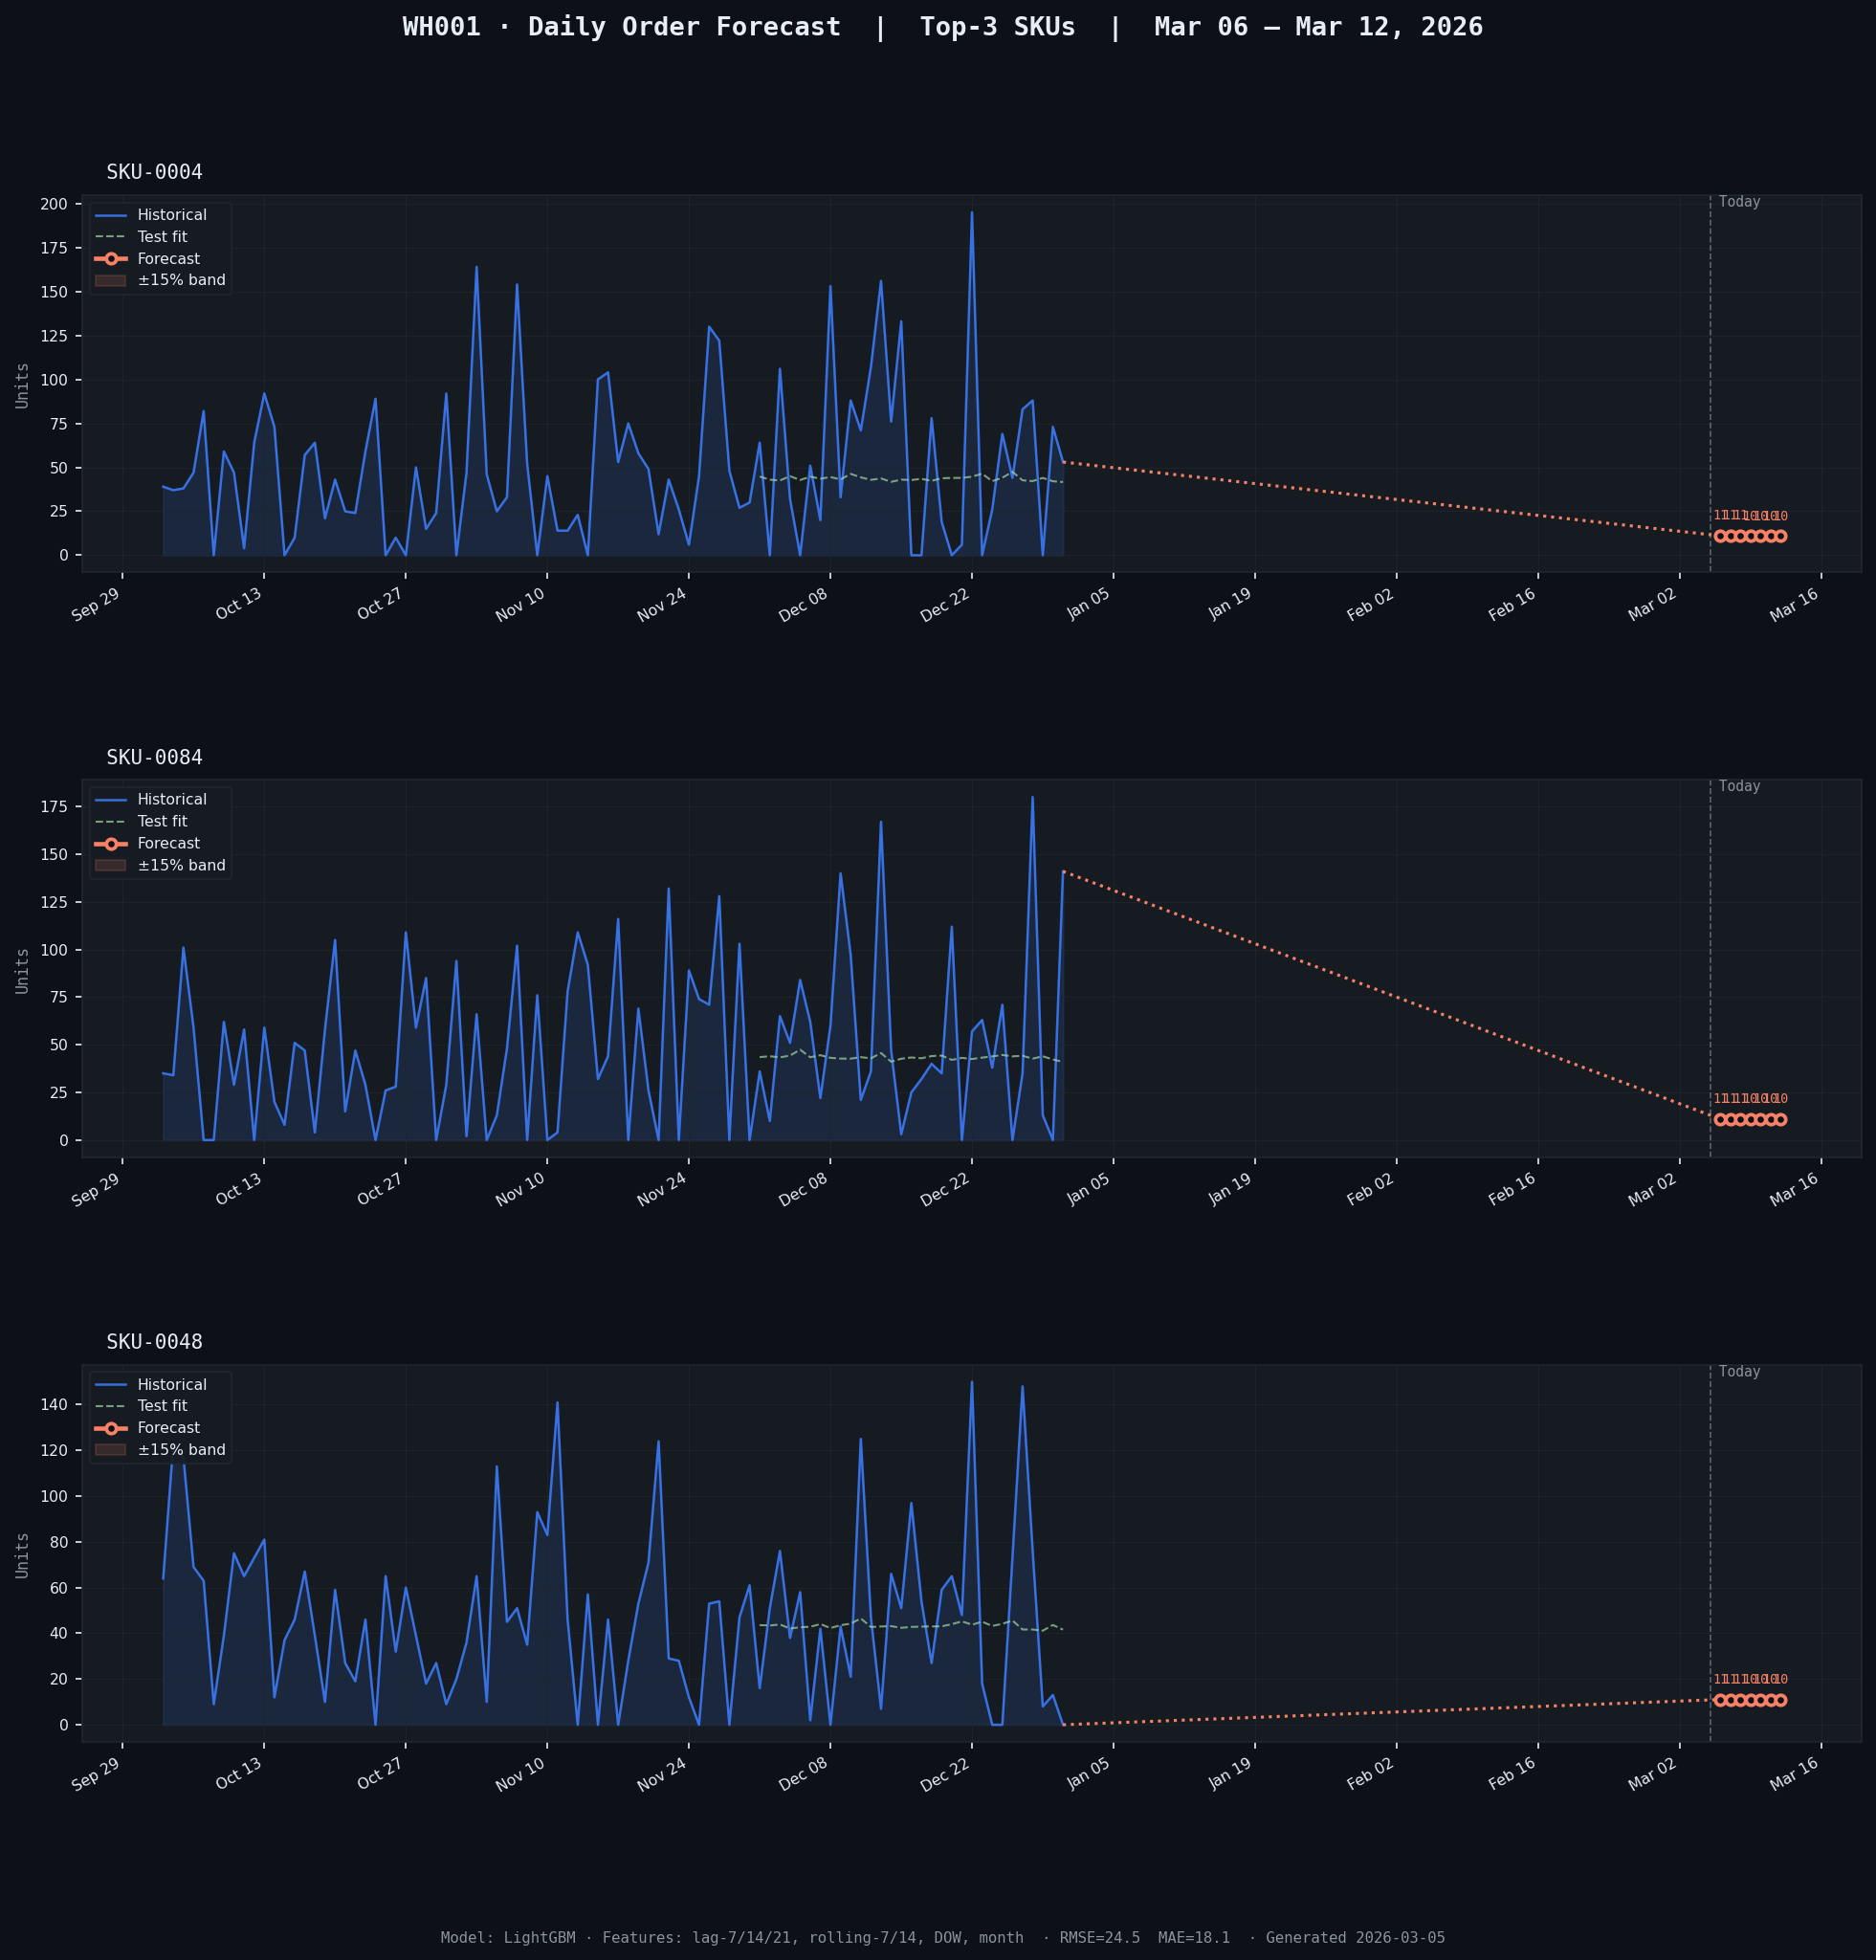


   💾 Chart saved: wh001_forecast_chart.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8. PLOT — industrial dark-theme dashboard
# ══════════════════════════════════════════════════════════════
print("\n🎨 Rendering forecast charts …")

DARK_BG   = "#0d1117"
PANEL_BG  = "#161b22"
GRID_COL  = "#21262d"
TEXT_COL  = "#e6edf3"
ACCENT    = "#58a6ff"
HIST_COL  = "#3d7eff"
FORE_COL  = "#f78166"
BAND_COL  = "#f7816622"
HIST_DAYS = 90   # days of history to show

fig, axes = plt.subplots(3, 1, figsize=(16, 14), facecolor=DARK_BG)
fig.subplots_adjust(hspace=0.55)

# Title banner
fig.text(
    0.5, 0.97,
    f"WH001 · Daily Order Forecast  |  Top-3 SKUs  |  "
    f"{forecast_dates[0].strftime('%b %d')} – {forecast_dates[-1].strftime('%b %d, %Y')}",
    ha="center", va="top",
    color=TEXT_COL, fontsize=13, fontweight="bold",
    fontfamily="monospace",
)

for ax, sku in zip(axes, top3_skus):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

    # ── Historical (last HIST_DAYS) ──────────────────────────
    sub_hist = (
        daily[daily["product_id"] == sku]
        .set_index("order_date")["total_qty"]
        .reindex(full_date_idx, fill_value=0)
        .iloc[-HIST_DAYS:]
    )
    ax.plot(
        sub_hist.index, sub_hist.values,
        color=HIST_COL, linewidth=1.2, alpha=0.85,
        label="Historical"
    )
    ax.fill_between(sub_hist.index, sub_hist.values, alpha=0.12, color=HIST_COL)

    # ── Test predictions (last 30 days in test) ──────────────
    sku_test = test_df[test_df["product_id"] == sku].copy()
    sku_test = sku_test[sku_test["order_date"] >= sku_test["order_date"].max() - pd.Timedelta(days=30)]
    if not sku_test.empty:
        sku_preds = model.predict(sku_test[FEATURE_COLS])
        ax.plot(
            sku_test["order_date"], sku_preds,
            color="#a5d6a7", linewidth=1.0, linestyle="--", alpha=0.7,
            label="Test fit"
        )

    # ── Forecast ─────────────────────────────────────────────
    sku_fore = forecast_df[forecast_df["product_id"] == sku]
    fore_dates = pd.to_datetime(sku_fore["forecast_date"])
    fore_vals  = sku_fore["predicted_qty"].values

    # Bridge last historical → first forecast
    last_date = sub_hist.index[-1]
    last_val  = sub_hist.values[-1]
    bridge_x  = [last_date, fore_dates.iloc[0]]
    bridge_y  = [last_val,  fore_vals[0]]
    ax.plot(bridge_x, bridge_y, color=FORE_COL, linewidth=1.5, linestyle=":")

    ax.plot(fore_dates, fore_vals,
            color=FORE_COL, linewidth=2.2, marker="o",
            markersize=5, markerfacecolor=DARK_BG,
            markeredgewidth=1.8, label="Forecast")

    # Confidence band  (±15% heuristic)
    ax.fill_between(
        fore_dates, fore_vals * 0.85, fore_vals * 1.15,
        color=FORE_COL, alpha=0.15, label="±15% band"
    )

    # Vertical divider at forecast start
    ax.axvline(today, color="#8b949e", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.text(today, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
            " Today", color="#8b949e", fontsize=7, va="top", fontfamily="monospace")

    # Annotations on forecast points
    for fd, fv in zip(fore_dates, fore_vals):
        ax.annotate(
            f"{int(fv)}",
            xy=(fd, fv), xytext=(0, 8),
            textcoords="offset points", ha="center",
            color=FORE_COL, fontsize=6.5, fontfamily="monospace",
        )

    # Formatting
    ax.set_title(f"  {sku}", color=TEXT_COL, fontsize=10,
                 fontfamily="monospace", loc="left", pad=8)
    ax.tick_params(colors=TEXT_COL, labelsize=7.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylabel("Units", color="#8b949e", fontsize=8, fontfamily="monospace")
    ax.grid(True, color=GRID_COL, linewidth=0.5, alpha=0.8)
    ax.legend(
        loc="upper left", fontsize=7.5,
        facecolor=PANEL_BG, edgecolor=GRID_COL,
        labelcolor=TEXT_COL, framealpha=0.9,
    )

# Footer
fig.text(
    0.5, 0.01,
    f"Model: LightGBM · Features: lag-7/14/21, rolling-7/14, DOW, month  "
    f"· RMSE={rmse:.1f}  MAE={mae:.1f}  · Generated {date.today()}",
    ha="center", color="#8b949e", fontsize=7.5, fontfamily="monospace",
)

chart_path = f"{OUT_DIR}/wh001_forecast_chart.png"
plt.savefig(chart_path, bbox_inches="tight", facecolor=DARK_BG, dpi=150)
plt.show()
print(f"\n   💾 Chart saved: wh001_forecast_chart.png")


📥 Loading data …
   ✔ Loaded 388,601 daily rows  |  Forecast: 2026-03-06 → 2026-03-12

📅 Forecast window : 2026-03-06 → 2026-03-12
   Historical comp  : same dates in [2023, 2024, 2025]

🏆 Top-3 SKUs: ['SKU-0084', 'SKU-0009', 'SKU-0115']

🎨 Rendering YoY comparison charts …


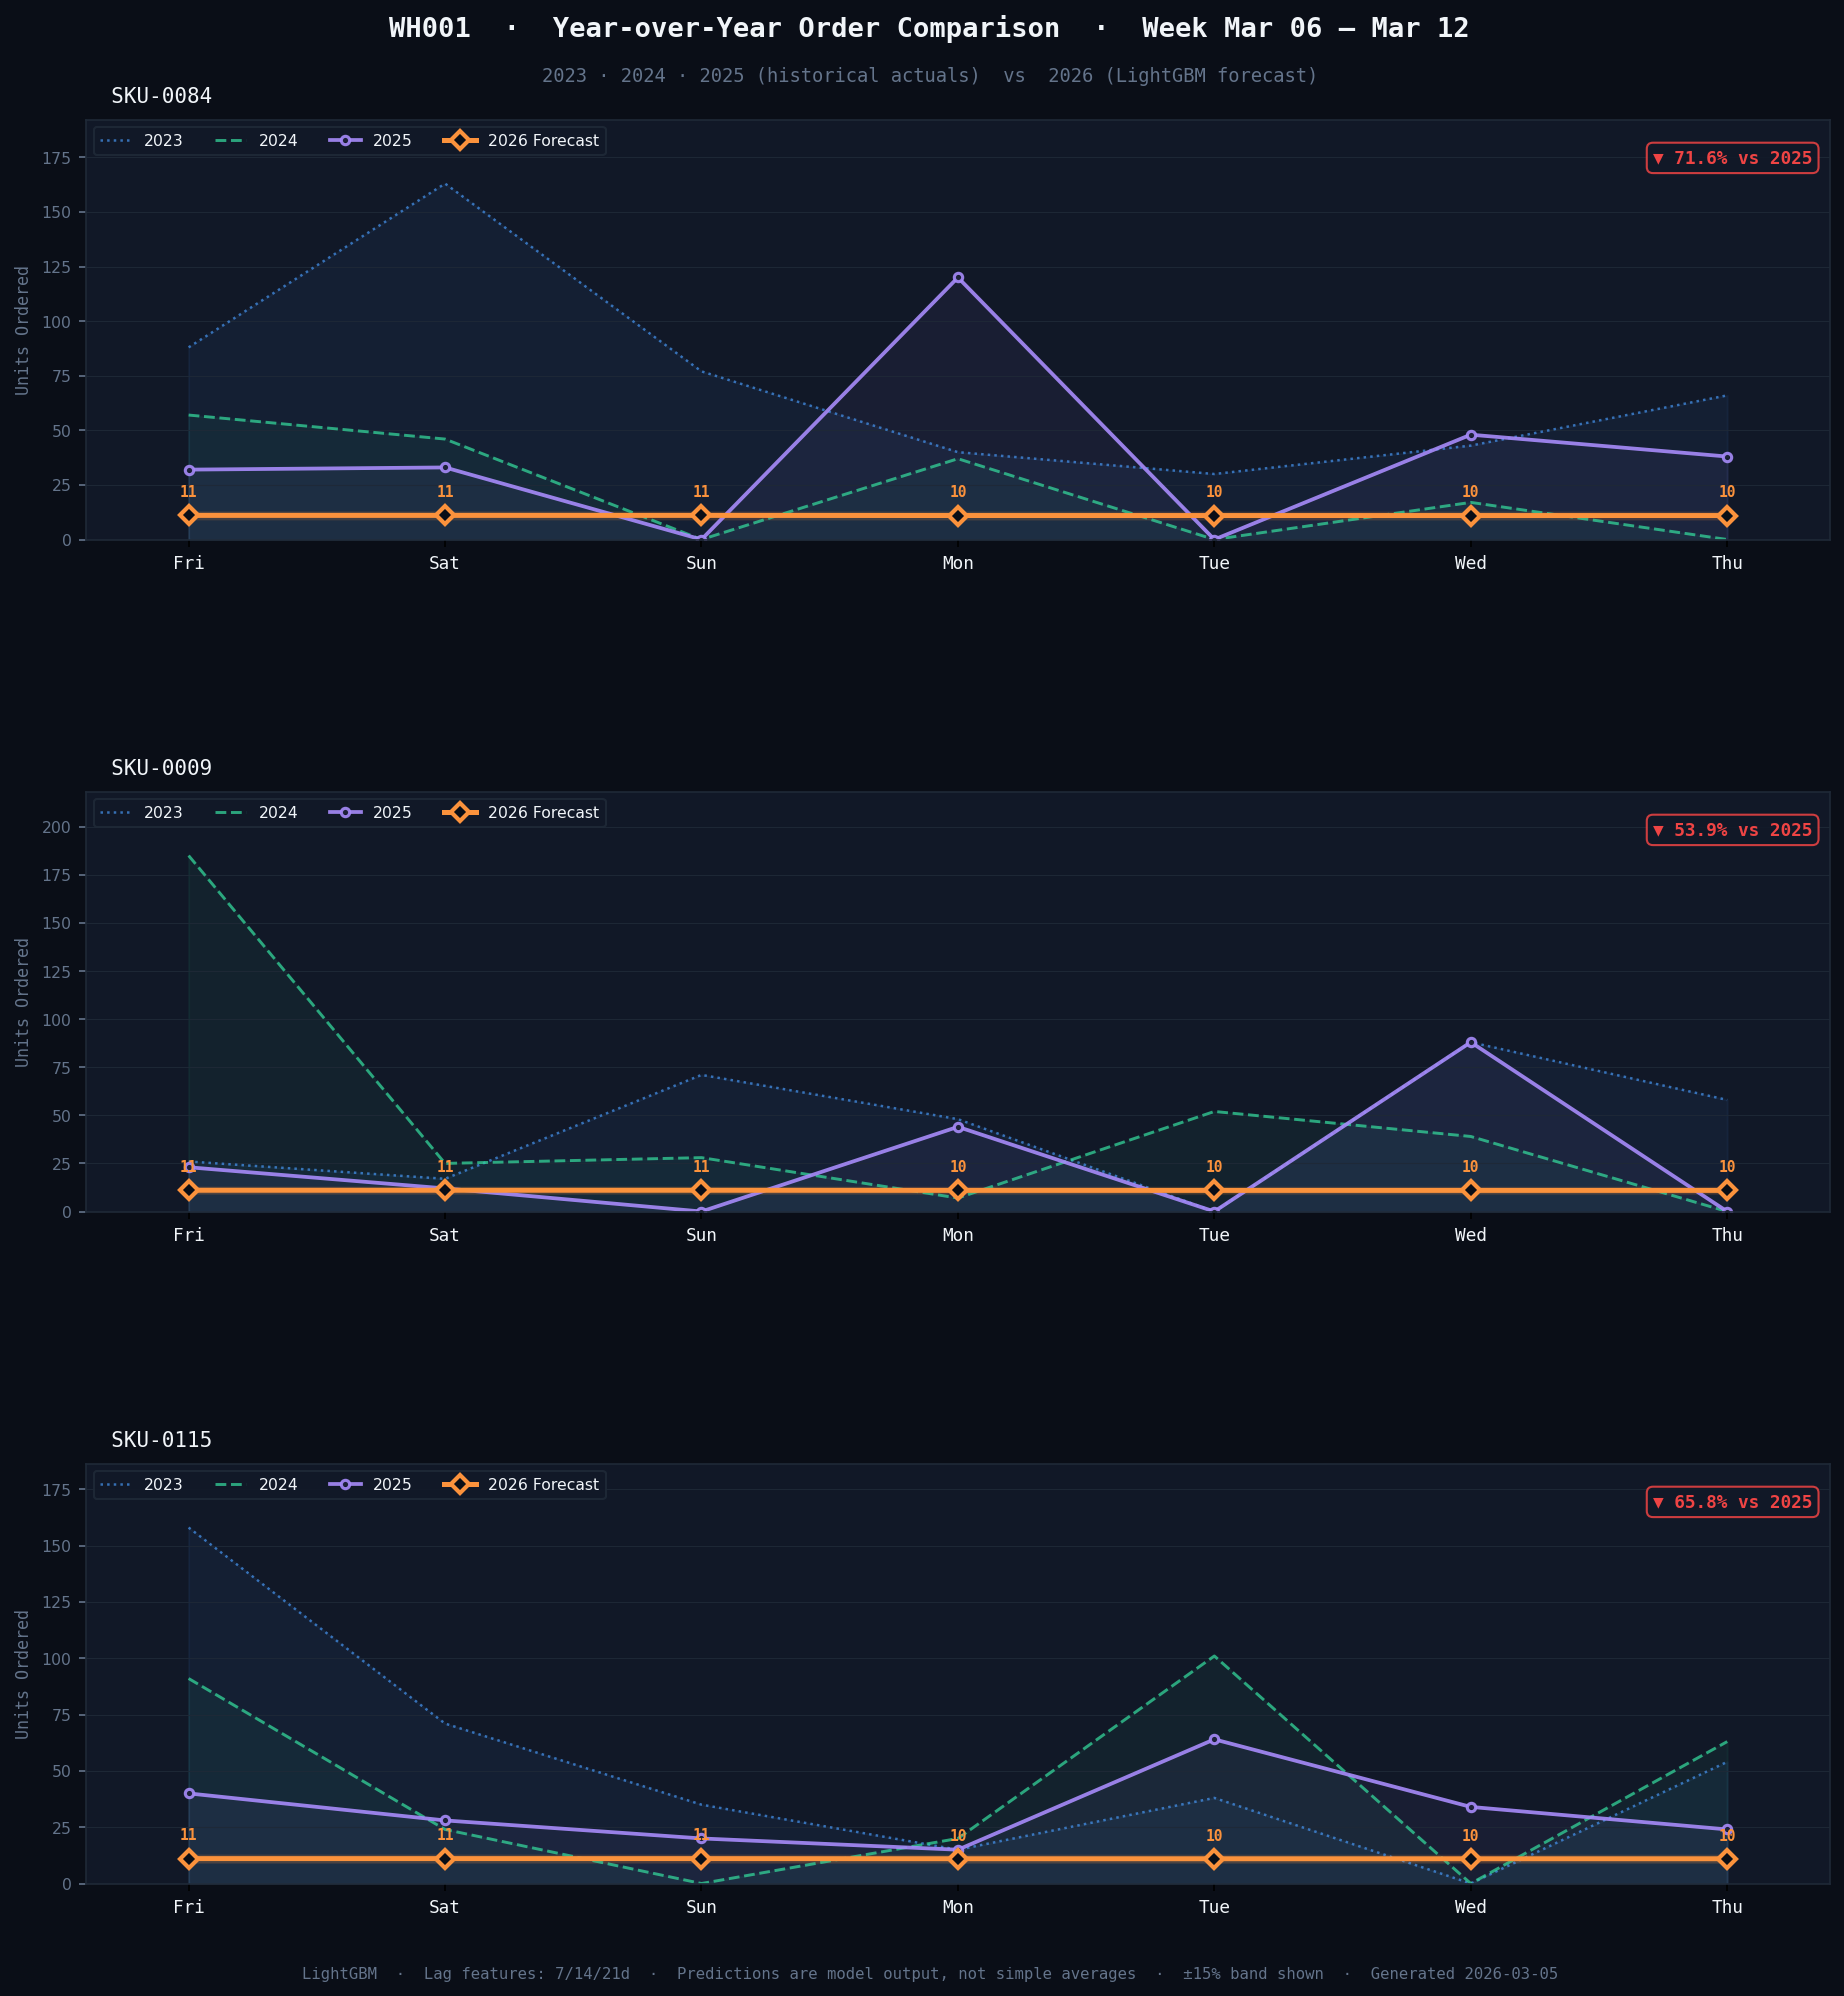


💾 Saved: wh001_yoy_comparison_chart.png
✅ Done.


In [ ]:


# ══════════════════════════════════════════════════════════════
# 1. LOAD PRE-BUILT ASSETS
# ══════════════════════════════════════════════════════════════
print("📥 Loading data …")

WH_ID = "WH001"

# Header (WH001 only)
hdr = pd.read_csv(
    f"{DATA_DIR}/fact_orders_header.csv",
    usecols=["order_id", "order_date", "warehouse_id"],
    parse_dates=["order_date"],
)
hdr = hdr[hdr["warehouse_id"] == WH_ID]
valid_ids = set(hdr["order_id"])

# Detail (chunked)
chunks = []
for chunk in pd.read_csv(f"{DATA_DIR}/fact_orders_detail.csv",
                         usecols=["order_id", "product_id", "ordered_qty"],
                         chunksize=500_000):
    chunks.append(chunk[chunk["order_id"].isin(valid_ids)])
detail = pd.concat(chunks, ignore_index=True)

# Daily grain per SKU
df = detail.merge(hdr[["order_id", "order_date"]], on="order_id")
daily = (
    df.groupby(["order_date", "product_id"], as_index=False)["ordered_qty"]
    .sum()
    .rename(columns={"ordered_qty": "total_qty"})
)
daily["order_date"] = pd.to_datetime(daily["order_date"])

# Forecast CSV (already generated)
forecast_df = pd.read_csv(f"{DATA_DIR}/lgbm_forecast_7day.csv",
                           parse_dates=["forecast_date"])

print(f"   ✔ Loaded {len(daily):,} daily rows  |  "
      f"Forecast: {forecast_df['forecast_date'].min().date()} → "
      f"{forecast_df['forecast_date'].max().date()}")


# ══════════════════════════════════════════════════════════════
# 2. DETERMINE FORECAST WINDOW & SAME-WEEK SLICES
# ══════════════════════════════════════════════════════════════
fore_start  = forecast_df["forecast_date"].min()
fore_end    = forecast_df["forecast_date"].max()
fore_month  = fore_start.month
fore_day_s  = fore_start.day
fore_day_e  = fore_end.day

COMPARE_YEARS = [2023, 2024, 2025]
FORE_YEAR     = fore_start.year   # 2026

print(f"\n📅 Forecast window : {fore_start.date()} → {fore_end.date()}")
print(f"   Historical comp  : same dates in {COMPARE_YEARS}")


def same_week_slice(daily_df: pd.DataFrame, sku: str, year: int,
                    month: int, day_start: int, day_end: int) -> pd.Series:
    """Return a Series of total_qty for sku over month/day_start–day_end in year."""
    try:
        start = pd.Timestamp(year, month, day_start)
        end   = pd.Timestamp(year, month, day_end)
    except ValueError:
        return pd.Series(dtype=float)

    mask = (
        (daily_df["product_id"] == sku) &
        (daily_df["order_date"] >= start) &
        (daily_df["order_date"] <= end)
    )
    sub = daily_df[mask].set_index("order_date")["total_qty"]
    full_idx = pd.date_range(start, end, freq="D")
    return sub.reindex(full_idx, fill_value=0)


# Top-3 SKUs by total volume over ALL history
top3_skus = (
    daily.groupby("product_id")["total_qty"]
    .sum()
    .nlargest(3)
    .index.tolist()
)
print(f"\n🏆 Top-3 SKUs: {top3_skus}")


# ══════════════════════════════════════════════════════════════
# 3. CHART — YoY same-week comparison + 2026 forecast
# ══════════════════════════════════════════════════════════════
print("\n🎨 Rendering YoY comparison charts …")

DARK_BG  = "#0a0e17"
PANEL_BG = "#111827"
GRID_COL = "#1f2937"
TEXT_COL = "#f1f5f9"
MUTED    = "#64748b"

# Year colour palette
YEAR_STYLES = {
    2023: {"color": "#4a9eff", "lw": 1.2, "ls": ":",  "alpha": 0.65, "marker": None},
    2024: {"color": "#34d399", "lw": 1.4, "ls": "--", "alpha": 0.75, "marker": None},
    2025: {"color": "#a78bfa", "lw": 1.8, "ls": "-",  "alpha": 0.90, "marker": "o"},
    FORE_YEAR: {"color": "#fb923c", "lw": 2.4, "ls": "-",  "alpha": 1.00, "marker": "D"},
}

fig, axes = plt.subplots(3, 1, figsize=(15, 14), facecolor=DARK_BG)
fig.subplots_adjust(hspace=0.60, top=0.91, bottom=0.07)

# ── Header banner ────────────────────────────────────────────
window_label = (
    f"Week {fore_start.strftime('%b %d')} – {fore_end.strftime('%b %d')}"
)
fig.text(0.5, 0.96,
         f"WH001  ·  Year-over-Year Order Comparison  ·  {window_label}",
         ha="center", va="top", color=TEXT_COL,
         fontsize=13, fontweight="bold", fontfamily="monospace")
fig.text(0.5, 0.935,
         f"2023 · 2024 · 2025 (historical actuals)  vs  {FORE_YEAR} (LightGBM forecast)",
         ha="center", va="top", color=MUTED, fontsize=9, fontfamily="monospace")

# Day-of-week x-labels (Mon … Sun)
x_positions = list(range(7))
x_labels    = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Compute actual day-of-week offset for the forecast start
dow_start  = fore_start.dayofweek   # 0=Mon
x_labels_shifted = x_labels[dow_start:] + x_labels[:dow_start]

for ax, sku in zip(axes, top3_skus):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

    all_vals = []

    # ── Historical years ─────────────────────────────────────
    for yr in COMPARE_YEARS:
        s = same_week_slice(daily, sku, yr,
                            fore_month, fore_day_s, fore_day_e)
        if s.empty:
            continue
        vals = s.values
        all_vals.extend(vals)
        st = YEAR_STYLES[yr]
        xs = list(range(len(vals)))
        ax.plot(xs, vals,
                color=st["color"], linewidth=st["lw"],
                linestyle=st["ls"], alpha=st["alpha"],
                marker=st["marker"] or "",
                markersize=4, markerfacecolor=PANEL_BG,
                markeredgewidth=1.5, label=str(yr))
        ax.fill_between(xs, vals, alpha=0.06, color=st["color"])

    # ── 2026 Forecast ─────────────────────────────────────────
    sku_fore = (
        forecast_df[forecast_df["product_id"] == sku]
        .sort_values("forecast_date")
    )
    fore_vals = sku_fore["predicted_qty"].values
    xs_fore   = list(range(len(fore_vals)))
    all_vals.extend(fore_vals)

    st = YEAR_STYLES[FORE_YEAR]
    ax.plot(xs_fore, fore_vals,
            color=st["color"], linewidth=st["lw"],
            linestyle=st["ls"], alpha=st["alpha"],
            marker=st["marker"], markersize=6,
            markerfacecolor=DARK_BG, markeredgewidth=2,
            zorder=5, label=f"{FORE_YEAR} Forecast")

    # ±15% band around forecast
    ax.fill_between(xs_fore,
                    fore_vals * 0.85, fore_vals * 1.15,
                    color=st["color"], alpha=0.12)

    # Annotate forecast values
    for xi, fv in zip(xs_fore, fore_vals):
        ax.annotate(f"{int(fv)}",
                    xy=(xi, fv), xytext=(0, 9),
                    textcoords="offset points", ha="center",
                    color=st["color"], fontsize=7, fontfamily="monospace",
                    fontweight="bold")

    # YoY % change badge (2025 → 2026 avg)
    s2025 = same_week_slice(daily, sku, 2025,
                            fore_month, fore_day_s, fore_day_e)
    if not s2025.empty and s2025.sum() > 0:
        pct_chg = (fore_vals.sum() - s2025.sum()) / s2025.sum() * 100
        badge_col = "#22c55e" if pct_chg >= 0 else "#ef4444"
        badge_txt = f"{'▲' if pct_chg >= 0 else '▼'} {abs(pct_chg):.1f}% vs 2025"
        ax.text(0.99, 0.93, badge_txt,
                transform=ax.transAxes, ha="right", va="top",
                color=badge_col, fontsize=8.5, fontfamily="monospace",
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.35", facecolor=PANEL_BG,
                          edgecolor=badge_col, alpha=0.85))

    # Axes formatting
    ax.set_title(f"  {sku}", color=TEXT_COL, fontsize=10,
                 fontfamily="monospace", loc="left", pad=8)
    ax.set_xticks(x_positions[:len(fore_vals)])
    ax.set_xticklabels(x_labels_shifted[:len(fore_vals)],
                       color=TEXT_COL, fontsize=8.5, fontfamily="monospace")
    ax.tick_params(axis="y", colors=MUTED, labelsize=7.5)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel("Units Ordered", color=MUTED, fontsize=8,
                  fontfamily="monospace")
    ax.grid(True, color=GRID_COL, linewidth=0.5, alpha=0.9, axis="y")
    ax.set_xlim(-0.4, 6.4)

    if all_vals:
        pad = max(all_vals) * 0.18
        ax.set_ylim(0, max(all_vals) + pad)

    ax.legend(loc="upper left", fontsize=7.5, ncol=4,
              facecolor=PANEL_BG, edgecolor=GRID_COL,
              labelcolor=TEXT_COL, framealpha=0.9)

# ── Footer ───────────────────────────────────────────────────
fig.text(0.5, 0.025,
         f"LightGBM  ·  Lag features: 7/14/21d  ·  Predictions are model output, "
         f"not simple averages  ·  ±15% band shown  ·  Generated {date.today()}",
         ha="center", color=MUTED, fontsize=7.5, fontfamily="monospace")

chart_path = f"{DATA_DIR}/wh001_yoy_comparison_chart.png"
plt.savefig(chart_path, bbox_inches="tight", facecolor=DARK_BG, dpi=150)
plt.show()
print(f"\n💾 Saved: wh001_yoy_comparison_chart.png")
print("✅ Done.")